# Covariance Analysis - Cars Dataset 2010-2020

This notebook analyzes the covariance between variables in the cars dataset.


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# Load the cars 2010-2020 dataset
cars_data = pd.read_csv("cars_2010_2020.csv")
print("Dataset loaded successfully!")
print(f"Dimensions: {cars_data.shape}")
cars_data.head()


Dataset loaded successfully!
Dimensions: (10000, 6)


,Make,Model,Year,Engine Size (L),Fuel Type,Price (USD)
0,Volkswagen,Jetta,2010,4.2,Petrol,54073.09
1,Honda,Pilot,2017,4.2,Hybrid,44924.91
2,Nissan,Murano,2011,4.2,Hybrid,76963.44
3,Toyota,RAV4,2010,2.4,Petrol,30871.25
4,Nissan,Altima,2010,3.6,Petrol,72037.65


In [ ]:
# Explore dataset structure
print("Dataset information:")
cars_data.info()
print("\n" + "="*50)
print("Descriptive statistics:")
cars_data.describe()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Make             10000 non-null  object 
 1   Model            10000 non-null  object 
 2   Year             10000 non-null  int64  
 3   Engine Size (L)  10000 non-null  float64
 4   Fuel Type        10000 non-null  object 
 5   Price (USD)      10000 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 468.9+ KB

Descriptive statistics:


,Year,Engine Size (L),Price (USD)
count,10000.000000,10000.000000,10000.000000
mean,2014.969900,2.992240,47397.584981
std,3.174303,1.150697,18643.431581
min,2010.000000,1.000000,15010.250000
25%,2012.000000,2.000000,31214.385000
50%,2015.000000,3.000000,47272.105000
75%,2018.000000,4.000000,63325.882500
max,2020.000000,5.000000,79998.870000


In [ ]:
# Identify numeric variables for covariance analysis
numeric_columns = cars_data.select_dtypes(include=['number']).columns
print("Numeric variables found:")
print(numeric_columns.tolist())

# Create subset with only numeric variables
numeric_data = cars_data[numeric_columns]
print(f"\nNumeric subset dimensions: {numeric_data.shape}")
numeric_data.head()


Numeric variables found:
['Year', 'Engine Size (L)', 'Price (USD)']

Numeric subset dimensions: (10000, 3)


,Year,Engine Size (L),Price (USD)
0,2010,4.2,54073.09
1,2017,4.2,44924.91
2,2011,4.2,76963.44
3,2010,2.4,30871.25
4,2010,3.6,72037.65


In [ ]:
# Calculate covariance matrix
covariance_matrix = numeric_data.cov()
print("Covariance Matrix:")
print("="*50)
print(covariance_matrix)


Covariance Matrix:
                       Year  Engine Size (L)   Price (USD)
Year              10.076202        -0.028036 -2.752322e+02
Engine Size (L)   -0.028036         1.324104  5.084968e+01
Price (USD)     -275.232227        50.849682  3.475775e+08


In [ ]:
# Detailed covariance analysis
print("Covariance Matrix Analysis:")
print("="*60)

# Find highest covariance values (excluding diagonal)
cov_values = []
for i in range(len(covariance_matrix.columns)):
    for j in range(i+1, len(covariance_matrix.columns)):
        var1 = covariance_matrix.columns[i]
        var2 = covariance_matrix.columns[j]
        cov_value = covariance_matrix.iloc[i, j]
        cov_values.append((var1, var2, cov_value))

# Sort by absolute covariance value
cov_values.sort(key=lambda x: abs(x[2]), reverse=True)

print("Top 5 highest covariances (by absolute value):")
print("-" * 60)
for i, (var1, var2, cov_val) in enumerate(cov_values[:5]):
    print(f"{i+1:2d}. {var1} - {var2}: {cov_val:12.2f}")

print("\nInterpretation:")
print("- Positive values: variables tend to increase together")
print("- Negative values: when one increases, the other tends to decrease")
print("- Values close to zero: little linear relationship between variables")


Covariance Matrix Analysis:
Top 5 highest covariances (by absolute value):
------------------------------------------------------------
 1. Year - Price (USD):      -275.23
 2. Engine Size (L) - Price (USD):        50.85
 3. Year - Engine Size (L):        -0.03

Interpretation:
- Positive values: variables tend to increase together
- Negative values: when one increases, the other tends to decrease
- Values close to zero: little linear relationship between variables


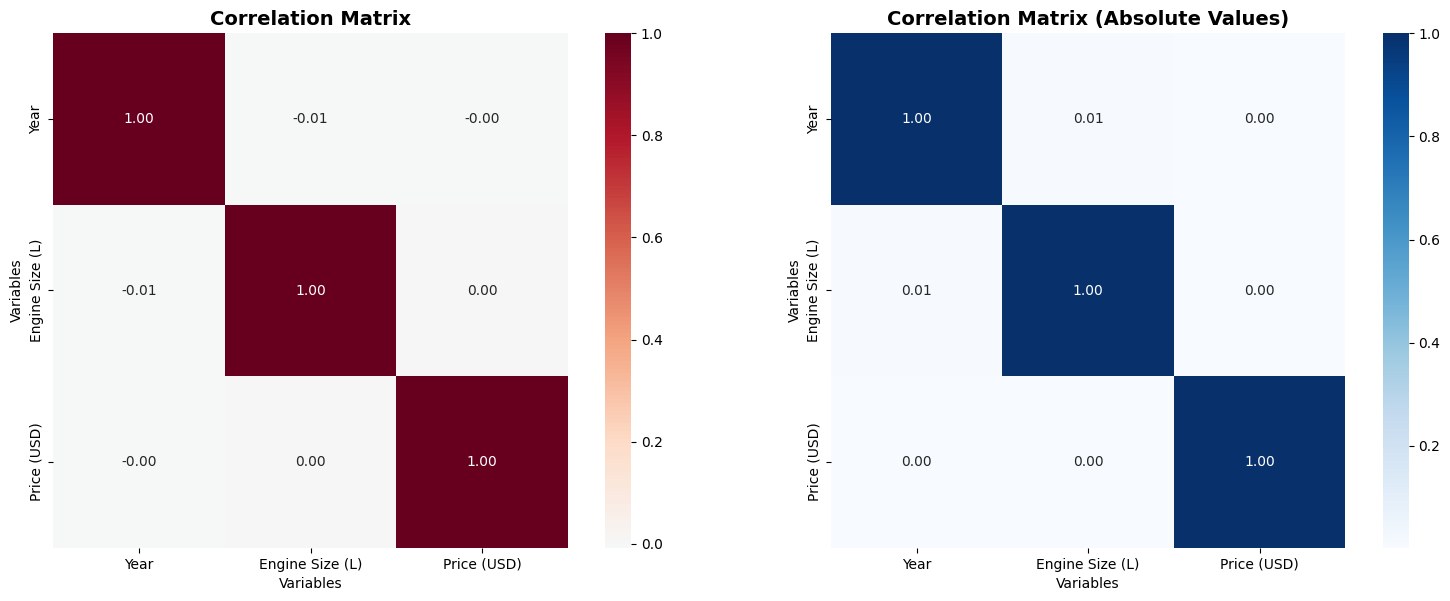


Correlation Matrix:
                     Year  Engine Size (L)  Price (USD)
Year             1.000000        -0.007676    -0.004651
Engine Size (L) -0.007676         1.000000     0.002370
Price (USD)     -0.004651         0.002370     1.000000


In [ ]:
# Correlation matrix visualization
plt.style.use('default')
sns.set_palette("viridis")

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of the correlation matrix
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.2f',
            square=True,
            ax=axes[0])
axes[0].set_title('Correlation Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Variables')
axes[0].set_ylabel('Variables')

# Heatmap of absolute correlation values for better visualization
sns.heatmap(correlation_matrix.abs(), 
            annot=True, 
            cmap='Blues',
            fmt='.2f',
            square=True,
            ax=axes[1])
axes[1].set_title('Correlation Matrix (Absolute Values)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Variables')
axes[1].set_ylabel('Variables')

plt.tight_layout()
plt.show()

# Show correlation matrix values
print("\nCorrelation Matrix:")
print("="*50)
print(correlation_matrix)


In [ ]:
# Detailed correlation analysis
print("CORRELATION MATRIX ANALYSIS:")
print("="*60)

# Find highest correlation values (excluding diagonal)
corr_values = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        var1 = correlation_matrix.columns[i]
        var2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        corr_values.append((var1, var2, corr_value))

# Sort by absolute correlation value
corr_values.sort(key=lambda x: abs(x[2]), reverse=True)

print("Top 5 highest correlations (by absolute value):")
print("-" * 60)
for i, (var1, var2, corr_val) in enumerate(corr_values[:5]):
    print(f"{i+1:2d}. {var1} - {var2}: {corr_val:12.2f}")

print("\nCorrelation Interpretation:")
print("- 1.0 to 0.7: Strong positive correlation")
print("- 0.7 to 0.3: Moderate positive correlation")
print("- 0.3 to -0.3: Weak or no correlation")
print("- -0.3 to -0.7: Moderate negative correlation")
print("- -0.7 to -1.0: Strong negative correlation")

# Summary and conclusions
print("\nCOVARIANCE & CORRELATION ANALYSIS SUMMARY")
print("="*60)
print(f"Dataset analyzed: cars_2010_2020.csv")
print(f"Total number of records: {len(cars_data):,}")
print(f"Numeric variables analyzed: {len(numeric_columns)}")
print(f"Variables: {', '.join(numeric_columns.tolist())}")

print(f"\nCovariance matrix statistics:")
print(f"- Maximum value: {covariance_matrix.max().max():.2f}")
print(f"- Minimum value: {covariance_matrix.min().min():.2f}")
print(f"- Range: {covariance_matrix.max().max() - covariance_matrix.min().min():.2f}")

print(f"\nCorrelation matrix statistics:")
print(f"- Maximum correlation: {correlation_matrix.max().max():.2f}")
print(f"- Minimum correlation: {correlation_matrix.min().min():.2f}")

# Find the highest correlation (excluding diagonal)
max_corr_idx = np.unravel_index(np.argmax(correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]), 
                                correlation_matrix.shape)
var1_max_corr = correlation_matrix.columns[max_corr_idx[0]]
var2_max_corr = correlation_matrix.columns[max_corr_idx[1]]
max_corr_value = correlation_matrix.iloc[max_corr_idx[0], max_corr_idx[1]]

print(f"\nHighest correlation found:")
print(f"- Variables: {var1_max_corr} and {var2_max_corr}")
print(f"- Value: {max_corr_value:.2f}")

print(f"\nInterpretation:")
if abs(max_corr_value) >= 0.7:
    strength = "strong"
elif abs(max_corr_value) >= 0.3:
    strength = "moderate"
else:
    strength = "weak"

if max_corr_value > 0:
    print(f"- Variables {var1_max_corr} and {var2_max_corr} have a {strength} positive correlation")
    print(f"- When one increases, the other tends to increase as well")
else:
    print(f"- Variables {var1_max_corr} and {var2_max_corr} have a {strength} negative correlation")
    print(f"- When one increases, the other tends to decrease")


CORRELATION MATRIX ANALYSIS:
Top 5 highest correlations (by absolute value):
------------------------------------------------------------
 1. Year - Engine Size (L):        -0.01
 2. Year - Price (USD):        -0.00
 3. Engine Size (L) - Price (USD):         0.00

Correlation Interpretation:
- 1.0 to 0.7: Strong positive correlation
- 0.7 to 0.3: Moderate positive correlation
- 0.3 to -0.3: Weak or no correlation
- -0.3 to -0.7: Moderate negative correlation
- -0.7 to -1.0: Strong negative correlation

COVARIANCE & CORRELATION ANALYSIS SUMMARY
Dataset analyzed: cars_2010_2020.csv
Total number of records: 10,000
Numeric variables analyzed: 3
Variables: Year, Engine Size (L), Price (USD)

Covariance matrix statistics:
- Maximum value: 347577541.12
- Minimum value: -275.23
- Range: 347577816.36

Correlation matrix statistics:
- Maximum correlation: 1.00
- Minimum correlation: -0.01

Highest correlation found:
- Variables: Year and Price (USD)
- Value: -0.00

Interpretation:
- Variables Ye